In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [46]:
import pickle
from src.operations2d import ImageChunk
from src.util import (
    read_video_frames,
    display_image,
    get_character_placeholder,
    read_trimesh,
    trimesh_to_opencv,
    opencv_to_trimesh_pose,
)
from src.operations2d import get_2d_bounding_boxes, bounding_boxes_to_image_chunks, find_similar_image_chunk
from src.operations3d import get_intrinsics_for_chunk, apply_mesh_transforms, adjust_transforms_by_chunk_rotation

In [107]:
video_path = "vids/moving_objects/wooden_cabinet.mp4"
frames = read_video_frames(video_path)
previous_frame = frames[0]
next_frame = frames[1]

In [108]:
# read mesh data from pkl
input_pkl = "output/wooden_cabinet.pkl"
with open(input_pkl, 'rb') as f:
            frames_data = pickle.load(f)
            
class_data = frames_data[0]["classes"][0]
object_class = class_data["class_name"]
mesh_data = class_data["reconstructed_meshes"][0]

unposed_path = mesh_data.get("unposed_mesh_path")
scale = mesh_data.get("scale")
rotation = mesh_data.get("rotation")
translation = mesh_data.get("translation")

chunk_relative_scale = mesh_data.get("chunk_relative_scale")
chunk_relative_rotation = mesh_data.get("chunk_relative_rotation")
chunk_relative_translation = mesh_data.get("chunk_relative_translation")

image_chunk_center = mesh_data.get("image_chunk_center")
image_chunk_size = mesh_data.get("image_chunk_size")

Detect objects and get image chunk that is close to previous one

In [109]:
previous_image_chunk = ImageChunk.from_image_point(previous_frame, image_chunk_center, image_chunk_size)

In [110]:
bounding_boxes = get_2d_bounding_boxes(next_frame, object_class)

Running dino in conda environment 'grounding_dino'...
Loading GroundingDINO model...
Using device: cpu
final text_encoder_type: bert-base-uncased
GroundingDINO model loaded.
Saved 1 bounding boxes




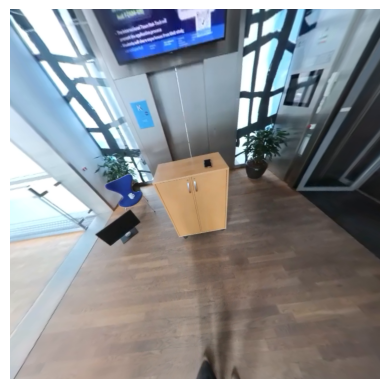

In [111]:
image_chunks = bounding_boxes_to_image_chunks(next_frame, bounding_boxes, orientation="horizontal")
next_image_chunk = find_similar_image_chunk(previous_image_chunk, image_chunks)
display_image(next_image_chunk.image)

In [112]:
# Get camera matrix
K = get_intrinsics_for_chunk(next_image_chunk)
K

array([[215.88321445,   0.        , 350.        ],
       [  0.        , 215.88321445, 350.        ],
       [  0.        ,   0.        ,   1.        ]])

Get object mesh in previous pose relative to camera in OpenCV format

In [ ]:
import numpy as np

unposed_mesh = read_trimesh(unposed_path)
identity_rotation = np.eye(3, dtype=np.float32)
zero_translation = np.zeros(3, dtype=np.float32)
scaled_mesh = apply_mesh_transforms(unposed_mesh, identity_rotation, zero_translation, chunk_relative_scale)


In [97]:
import cv2

cv_vertices, cv_tris, cv_rotation_mat, cv_translation = trimesh_to_opencv(
    scaled_mesh,
    rotation_matrix=mesh_data.get("chunk_relative_rotation"),
    translation_vector=mesh_data.get("chunk_relative_translation"),
)

cv_rotation, _ = cv2.Rodrigues(cv_rotation_mat)

Run RAPID and apply new transforms to object

In [98]:
# extract contour points
contour_points_2d, contour_points_3d = cv2.rapid.extractControlPoints(
    30,
    50,
    cv_vertices,
    cv_rotation,
    cv_translation,
    K,
    next_image_chunk.image.shape[:2],
    cv_tris,
)

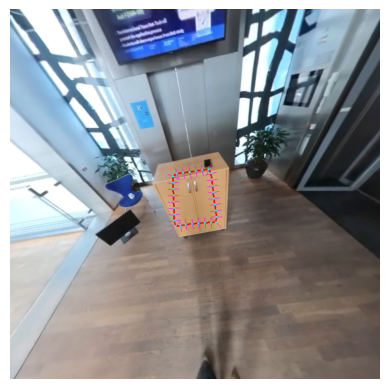

In [102]:
# visualize contour points
contour_overlay = next_image_chunk.image.copy()

contour = contour_points_2d.reshape(-1, 2).astype(np.int32)
cv2.polylines(contour_overlay, [contour], isClosed=True, color=(255, 0, 0), thickness=2)

for pt in contour:
    cv2.circle(contour_overlay, tuple(pt), 2, (0, 255, 255), -1)

display_image(contour_overlay)

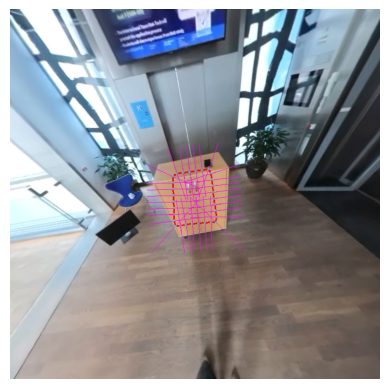

In [ ]:
# extract line bundle
bundle, src_locations = cv2.rapid.extractLineBundle(
    50,
    contour_points_2d,
    next_image_chunk.image,
)
bundle_overlay = contour_overlay.copy()
bundle_overlay = cv2.rapid.drawSearchLines(
    bundle_overlay,
    src_locations,
    (255, 0, 255)
)
display_image(bundle_overlay)


In [ ]:
# find correspondencies
cols, response = cv2.rapid.findCorrespondencies(
    bundle
)
correspondencies_2d, correspondencies_3d = cv2.rapid.convertCorrespondencies(
    cols,
    src_locations
)


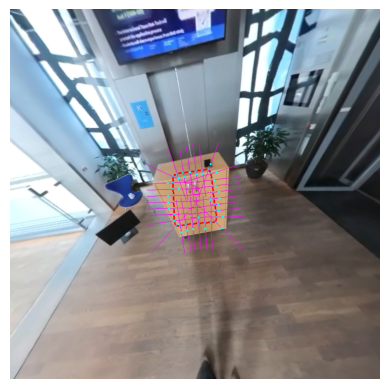

In [83]:
correspondencies_overlay = bundle_overlay.copy()

correspondencies = correspondencies_2d.reshape(-1, 2).astype(np.int32)
for pt in correspondencies:
    cv2.circle(correspondencies_overlay, tuple(pt), 2, (0, 255, 255), -1)

display_image(correspondencies_overlay)

In [84]:
# all in one
_, cv_rotation_new, cv_translation_new, _ = cv2.rapid.rapid(
    img=next_image_chunk.image,
    num=30,
    len=50,
    pts3d=cv_vertices,
    tris=cv_tris,
    K=K,
    rvec=cv_rotation,
    tvec=cv_translation
)

In [ ]:
# convert opencv back to trimesh
next_rotation_cv, _ = cv2.Rodrigues(cv_rotation_new)
next_translation_cv = cv_translation_new.reshape(3)

next_rotation_chunk, next_translation_chunk = opencv_to_trimesh_pose(
    next_rotation_cv,
    next_translation_cv,
)

# Pose in world
rot, trans = adjust_transforms_by_chunk_rotation([next_rotation_chunk], [next_translation_chunk], next_image_chunk)
next_rotation_world = rot[0]
next_translation_world = trans[0]

Visualize pose difference

In [86]:
unposed_mesh = read_trimesh(unposed_path)
next_world_mesh = apply_mesh_transforms(unposed_mesh, next_rotation_world, next_translation_world, scale)
unposed_mesh = read_trimesh(unposed_path)
previous_world_mesh = apply_mesh_transforms(unposed_mesh, rotation, translation, scale)

In [87]:
import open3d as o3d
from src.util import trimesh_to_open3d, render_scene
character_placeholder = get_character_placeholder()
coordinate_frame = o3d.geometry.TriangleMesh.create_coordinate_frame(size=0.55, origin=[0, 0, 0])

render_scene([trimesh_to_open3d(previous_world_mesh).paint_uniform_color([1, 0, 0]),
              trimesh_to_open3d(next_world_mesh).paint_uniform_color([0, 1, 0]),
              character_placeholder,
              coordinate_frame])